# SteamRec Evaluation Notebook (MongoDB)
This notebook evaluates recommendation approaches using your MongoDB data.
We will:
- Load data from `games` and `interactions`
- Clean and preprocess interactions
- Build train/test split
- Build a baseline recommender
- Train a library model (ALS)
- Compare models with Precision/Recall/NDCG
- Run a small hyperparameter search

## Wat verwachten we?
We willen aantonen dat het recommender‑systeem:
- **Consistente kwaliteit** levert op ranking‑metrics (Precision@K/Recall@K/NDCG@K).
- **Beter presteert dan een eenvoudige baseline** (popularity).
- **Stabiel** is over verschillende train/test splits (cross‑validation) zodat we niet over‑fitten op één split.

**Succescriteria (indicatief):**
- Model > baseline op NDCG@10 en Recall@10.
- Verschil is **herhaalbaar** over CV‑folds (geen toevals‑uitschieters).


## Imports
We load Python libraries for data handling, modeling, and evaluation.

In [1]:
import os
import pandas as pd
import numpy as np
from pymongo import MongoClient

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt

## Connect to MongoDB
We connect to the `steamrec-test` database and load the `games` and `interactions` collections into DataFrames.

In [2]:
MONGO_URI = os.getenv("MONGODB_CONNECTION_STRING", "mongodb://localhost:27017")
DB_NAME = "steamrec-test"

client = MongoClient(MONGO_URI)
db = client[DB_NAME]

games = pd.DataFrame(list(db["games"].find({})))
interactions = pd.DataFrame(list(db["interactions"].find({})))

print("games:", games.shape)
print("interactions:", interactions.shape)


games: (150405, 18)
interactions: (27150, 7)


## Inspect the raw data
We quickly inspect the first few rows so we can confirm the schema matches our expectations.

In [3]:
games.head(3)

,_id,AppId,Name,Genres,Categories,Tags,PriceEur,MetacriticScore,ReleaseYear,RequiredAge,IsFree,ReviewPositive,ReviewNegative,ReviewTotal,ReviewRatio,ReviewScoreAdj,ReviewVolumeLog,UpdatedUtc
0,6942ff9199ef832464837203,10,Counter-Strike,Action,Multi-player;PvP;Online PvP;Shared/Split Scree...,Action;FPS;Multiplayer;Shooter;Classic;Team-Ba...,1.63,88.0,2000,0,False,249308.0,6599.0,255907,0.974213,0.973592,5.408082,2025-12-28 10:30:47.772
1,6942ff9199ef832464837204,20,Team Fortress Classic,Action,Multi-player;PvP;Online PvP;Shared/Split Scree...,Action;FPS;Multiplayer;Classic;Hero Shooter;Sh...,1.24,0.0,1999,0,False,7806.0,1150.0,8956,0.871594,0.864506,3.952114,2025-12-28 10:30:33.449
2,6942ff9199ef832464837205,30,Day of Defeat,Action,Multi-player;Camera Comfort;Color Alternatives...,FPS;World War II;Multiplayer;Shooter;Action;Wa...,1.24,79.0,2003,0,False,6508.0,699.0,7207,0.903011,0.895962,3.857755,2025-12-28 10:30:49.222


## Inspect interactions
We check the playtime fields because they are key signals for our implicit rating.

In [4]:
interactions.head(3)

,_id,SteamId,AppId,PlaytimeForever,Playtime2Weeks,CreatedUtc,UpdatedUtc
0,000000000000000000000000,76561198164987397,220,182.0,0.0,2025-12-17 19:42:36.009,2026-01-04 02:48:55.870
1,69430a9999ef83246483b402,76561198080219056,220,793.0,0.0,NaT,2025-12-28 21:24:59.764
2,69430a9999ef83246483b403,76561198080219056,400,208.0,0.0,NaT,2025-12-28 21:24:59.764


## Explain the implicit rating formula
We use:

    log(1 + playtime_forever) + 0.35 * log(1 + playtime_2weeks)

**What it does:**
- `log(1 + playtime)` compresses large playtimes so a few huge values do not dominate.
- The `+1` avoids `log(0)` when playtime is zero.
- The `0.35` gives **recent playtime** some extra weight, without letting it overpower total playtime.

**Why we do this:**
- Raw minutes are extremely skewed (a few users play thousands of hours).
- Log scaling makes the data more stable and improves training.
- Recent playtime helps capture short‑term interest.

## Clean interactions
We remove:
- Missing Steam IDs or App IDs
- Zero playtime (no signal)
Then we compute the implicit rating using the same logic as your ML.NET model.

In [5]:
interactions = interactions.dropna(subset=["SteamId", "AppId"])
interactions = interactions[interactions["AppId"] > 0]

# Remove zero-signal rows
interactions = interactions[
    (interactions["PlaytimeForever"] > 0) | (interactions["Playtime2Weeks"] > 0)
]

# Implicit rating (same formula as ML.NET)
interactions["implicit_rating"] = (
    np.log1p(interactions["PlaytimeForever"].clip(lower=0))
    + 0.35 * np.log1p(interactions["Playtime2Weeks"].clip(lower=0))
)

interactions = interactions[interactions["implicit_rating"] > 0]
interactions.shape

(27150, 8)

## Filter low-signal users and games
If a user only has 1 interaction or a game only appears once, the model can’t learn patterns.
We filter them to reduce noise.

In [6]:
min_user_interactions = 5
min_game_interactions = 5

user_counts = interactions["SteamId"].value_counts()
game_counts = interactions["AppId"].value_counts()

valid_users = user_counts[user_counts >= min_user_interactions].index
valid_games = game_counts[game_counts >= min_game_interactions].index

interactions = interactions[
    interactions["SteamId"].isin(valid_users)
    & interactions["AppId"].isin(valid_games)
]

interactions.shape

(5675, 8)

## Quick EDA
We view distributions to understand data size and sparsity.

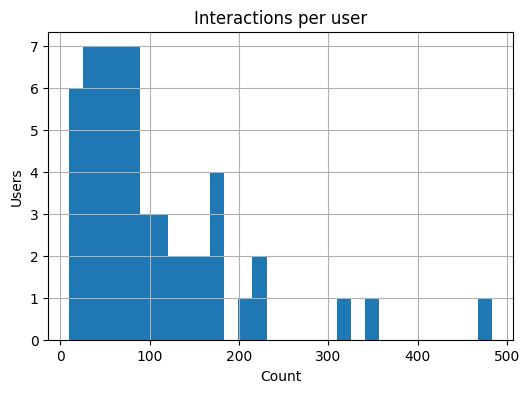

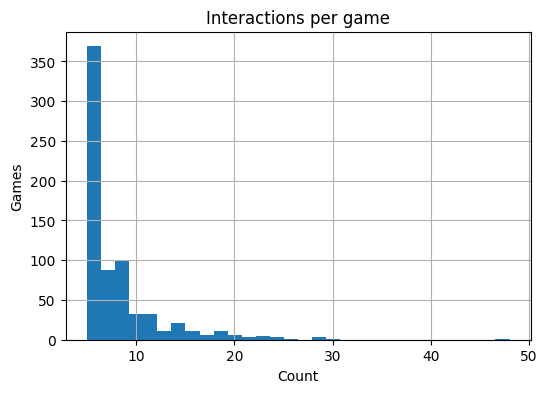

In [7]:
plt.figure(figsize=(6,4))
interactions["SteamId"].value_counts().hist(bins=30)
plt.title("Interactions per user")
plt.xlabel("Count")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(6,4))
interactions["AppId"].value_counts().hist(bins=30)
plt.title("Interactions per game")
plt.xlabel("Count")
plt.ylabel("Games")
plt.show()

## Train/Test Split (leave-one-out per user)
We hold out one interaction per user as a test item.
This is common for recommender evaluation.

In [8]:
interactions = interactions.sort_values("implicit_rating", ascending=False)

test_rows = interactions.groupby("SteamId").head(1)
train_rows = interactions.drop(test_rows.index)

print("train:", train_rows.shape, "test:", test_rows.shape)

train: (5619, 8) test: (56, 8)


## Build user-item matrix
We map SteamId and AppId to matrix indices and build a sparse matrix.

In [9]:
user_ids = train_rows["SteamId"].unique()
item_ids = train_rows["AppId"].unique()

user_index = {u:i for i,u in enumerate(user_ids)}
item_index = {a:i for i,a in enumerate(item_ids)}
inv_item_index = {i:a for a,i in item_index.items()}

train_rows = train_rows.copy()
train_rows["u_idx"] = train_rows["SteamId"].map(user_index)
train_rows["i_idx"] = train_rows["AppId"].map(item_index)

matrix = csr_matrix(
    (train_rows["implicit_rating"], (train_rows["u_idx"], train_rows["i_idx"])),
    shape=(len(user_ids), len(item_ids))
)

## Baseline model: Popularity
A simple baseline: recommend the most played games.
This is used to compare against more complex models.

In [10]:
popularity = train_rows.groupby("AppId")["implicit_rating"].sum().sort_values(ascending=False)

def recommend_popular(user_id, k=10):
    seen = set(train_rows[train_rows["SteamId"] == user_id]["AppId"])
    return [appid for appid in popularity.index if appid not in seen][:k]

## Evaluation Metrics (Precision@K, Recall@K, NDCG@K)
These metrics measure ranking quality.
- Precision@K: how many recommended items are correct
- Recall@K: how many relevant items were retrieved
- NDCG@K: rewards correct items near the top of the list

### Waarom geen MAE/RMSE?
MAE/RMSE zijn **regressiemetrics** voor expliciete ratings. In dit project gebruiken we **implicit feedback** (playtime‑signaal),
waardoor ranking‑metrics (Precision/Recall/NDCG) beter passen. MAE/RMSE zouden hier weinig betekenis hebben zonder expliciete ratings.


In [11]:
def precision_recall_ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    hits = [1 if r in relevant else 0 for r in recommended]
    precision = np.sum(hits) / k if k else 0
    recall = np.sum(hits) / len(relevant) if relevant else 0
    
    dcg = np.sum([h / np.log2(i+2) for i,h in enumerate(hits)])
    idcg = np.sum([1 / np.log2(i+2) for i in range(min(len(relevant), k))])
    ndcg = dcg / idcg if idcg > 0 else 0
    return precision, recall, ndcg

## Evaluation loop
We test a recommendation function across all users.

In [12]:
def evaluate_model(recommend_fn, k=10):
    precisions, recalls, ndcgs = [], [], []
    
    for user_id, row in test_rows.groupby("SteamId"):
        relevant = set(row["AppId"])
        recs = recommend_fn(user_id, k)
        p, r, n = precision_recall_ndcg_at_k(recs, relevant, k)
        precisions.append(p)
        recalls.append(r)
        ndcgs.append(n)
    
    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)

## Cross‑validation (user‑based)
Voor recommender‑systemen is klassieke k‑fold CV lastig omdat gebruikersinteracties niet onafhankelijk zijn.
We gebruiken daarom **user‑based splits** (leave‑one‑out per user) en herhalen dit meerdere keren door de test‑interactie te variëren.


In [ ]:
from implicit.als import AlternatingLeastSquares


def build_train_test_leave_one_out(df, random_state=None):
    # Randomize within user to get a different held‑out item each run
    df = df.sample(frac=1.0, random_state=random_state).sort_values("SteamId")
    test = df.groupby("SteamId").head(1)
    train = df.drop(test.index)
    return train, test

# Simple repeated evaluation (lightweight CV proxy)
cv_scores = []
for seed in [1, 7, 21]:
    train_rows_cv, test_rows_cv = build_train_test_leave_one_out(interactions, random_state=seed)

    # build matrix for CV split
    user_ids_cv = train_rows_cv["SteamId"].unique()
    item_ids_cv = train_rows_cv["AppId"].unique()
    user_index_cv = {u:i for i,u in enumerate(user_ids_cv)}
    item_index_cv = {a:i for i,a in enumerate(item_ids_cv)}
    inv_item_index_cv = {i:a for a,i in item_index_cv.items()}

    tmp = train_rows_cv.copy()
    tmp["u_idx"] = tmp["SteamId"].map(user_index_cv)
    tmp["i_idx"] = tmp["AppId"].map(item_index_cv)
    matrix_cv = csr_matrix(
        (tmp["implicit_rating"], (tmp["u_idx"], tmp["i_idx"])),
        shape=(len(user_ids_cv), len(item_ids_cv))
    )

    model_cv = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=10)
    model_cv.fit(matrix_cv)

    def recommend_cv(user_id, k=10):
        if user_id not in user_index_cv:
            return []
        uid = user_index_cv[user_id]
        ids, scores = model_cv.recommend(uid, matrix_cv[uid], N=k)
        return [inv_item_index_cv[int(i)] for i in ids if int(i) in inv_item_index_cv]

    # evaluate on this split
    old_test = test_rows
    test_rows = test_rows_cv
    scores = evaluate_model(recommend_cv, k=10)
    cv_scores.append(scores)
    test_rows = old_test

cv_scores


## Evaluate baseline popularity model
This gives a reference point before using more complex models.

In [13]:
baseline_scores = evaluate_model(recommend_popular, k=10)
baseline_scores

(np.float64(0.03928571428571429),
 np.float64(0.39285714285714285),
 np.float64(0.377338031313776))

## Train ALS (library model)
We use the `implicit` library to train Alternating Least Squares (matrix factorization).

In [14]:
from implicit.als import AlternatingLeastSquares

# Rebuild matrices from current train_rows
user_ids = train_rows["SteamId"].unique()
item_ids = train_rows["AppId"].unique()

user_index = {u:i for i,u in enumerate(user_ids)}
item_index = {a:i for i,a in enumerate(item_ids)}
inv_item_index = {i:a for a,i in item_index.items()}

train_rows = train_rows.copy()
train_rows["u_idx"] = train_rows["SteamId"].map(user_index)
train_rows["i_idx"] = train_rows["AppId"].map(item_index)

matrix = csr_matrix(
    (train_rows["implicit_rating"], (train_rows["u_idx"], train_rows["i_idx"])),
    shape=(len(user_ids), len(item_ids))
)

# ✅ Train on user-item matrix (NOT transposed)
als = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=20)
als.fit(matrix)

print("matrix shape (users, items):", matrix.shape)
print("als user_factors:", als.user_factors.shape)   # should be (users, factors)
print("als item_factors:", als.item_factors.shape)   # should be (items, factors)

def recommend_als(user_id, k=10):
    if user_id not in user_index:
        return []
    uid = user_index[user_id]
    ids, scores = als.recommend(uid, matrix[uid], N=k)
    return [inv_item_index[int(i)] for i in ids if int(i) in inv_item_index]

als_scores = evaluate_model(recommend_als, k=10)
als_scores

c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:00<00:00, 398.21it/s]

matrix shape (users, items): (56, 707)
als user_factors: (56, 64)
als item_factors: (707, 64)


(np.float64(0.028571428571428574),
 np.float64(0.2857142857142857),
 np.float64(0.12986810024571468))

## Hyperparameter search
We test different ALS configurations and compare results.

In [16]:
param_grid = [
    {"factors": 32, "regularization": 0.01},
    {"factors": 64, "regularization": 0.05},
    {"factors": 128, "regularization": 0.1},
]

results = []
for params in param_grid:
    model = AlternatingLeastSquares(
        factors=params["factors"],
        regularization=params["regularization"],
        iterations=20
    )
    model.fit(matrix)
    
    def recommend_tmp(user_id, k=10):
        if user_id not in user_index:
            return []
        uid = user_index[user_id]
        ids, scores = model.recommend(uid, matrix[uid], N=k)
        return [inv_item_index[int(i)] for i in ids if int(i) in inv_item_index]
    
    scores = evaluate_model(recommend_tmp, k=10)
    results.append((params, scores))

results

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 649.52it/s]


[({'factors': 32, 'regularization': 0.01},
  (np.float64(0.0125), np.float64(0.125), np.float64(0.0680184096011789))),
 ({'factors': 64, 'regularization': 0.05},
  (np.float64(0.03214285714285714),
   np.float64(0.32142857142857145),
   np.float64(0.14446082924793555))),
 ({'factors': 128, 'regularization': 0.1},
  (np.float64(0.0375), np.float64(0.375), np.float64(0.16031961870067504)))]

## Content-based evaluation (metadata similarity)
We build a content-based recommender from game metadata (genres/tags + numeric features).
For each user, we recommend games similar to their known games and evaluate with Precision@10, Recall@10, NDCG@10.

In [17]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from scipy.sparse import csr_matrix, hstack

# Only keep games that appear in the interactions dataset
active_appids = interactions["AppId"].unique()
games_cb = games[games["AppId"].isin(active_appids)].copy()

def split_field(val):
    if isinstance(val, str) and val.strip():
        return [x.strip() for x in val.split(",") if x.strip()]
    return []

games_cb["genres_list"] = games_cb["Genres"].apply(split_field)
games_cb["tags_list"] = games_cb["Tags"].apply(split_field)

# Sparse binary encodings
mlb_genres = MultiLabelBinarizer(sparse_output=True)
mlb_tags = MultiLabelBinarizer(sparse_output=True)

genre_features = mlb_genres.fit_transform(games_cb["genres_list"])
tag_features = mlb_tags.fit_transform(games_cb["tags_list"])

# Numeric features (dense but small)
numeric_cols = ["PriceEur", "MetacriticScore", "ReviewScoreAdj", "ReviewVolumeLog"]
numeric_data = games_cb[numeric_cols].fillna(0.0)

scaler = StandardScaler()
numeric_features = scaler.fit_transform(numeric_data)

# Convert numeric to sparse and combine
numeric_sparse = csr_matrix(numeric_features)
content_features = hstack([genre_features, tag_features, numeric_sparse], format="csr")

# Map AppId -> row index for this filtered set
game_index = {appid: i for i, appid in enumerate(games_cb["AppId"])}


## Content-based recommend function
We compute the average feature vector of a user's known games, then rank all games by cosine similarity.

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_content_based(user_id, k=10):
    if user_id not in train_rows["SteamId"].values:
        return []
    
    user_games = train_rows[train_rows["SteamId"] == user_id]["AppId"].tolist()
    user_games = [g for g in user_games if g in game_index]
    
    if not user_games:
        return []
    
    user_vecs = content_features[[game_index[g] for g in user_games]]
    user_profile = user_vecs.mean(axis=0)

    # Convert np.matrix to ndarray
    if hasattr(user_profile, "A"):
        user_profile = user_profile.A  # converts to ndarray

    sims = cosine_similarity(user_profile, content_features).flatten()
    
    known_set = set(user_games)
    ranked = np.argsort(-sims)

    recs = []
    for idx in ranked:
        appid = games_cb.iloc[idx]["AppId"]
        if appid in known_set:
            continue
        recs.append(appid)
        if len(recs) >= k:
            break

    return recs

## Evaluate content-based model
We measure Precision@10, Recall@10, NDCG@10 just like ALS and baseline.

In [19]:
content_scores = evaluate_model(recommend_content_based, k=10)
content_scores

(np.float64(0.021428571428571432),
 np.float64(0.21428571428571427),
 np.float64(0.13499028441751856))

## Forecasting‑gebaseerde aanbevelingen (seizoens‑trends)
We hebben **geen voldoende rijke tijdreeks** (bv. maandelijkse activiteit per game) om betrouwbare seizoens‑/trendmodellen te trainen.
De huidige dataset bevat vooral totale playtime + 2‑weeks playtime; dit is niet genoeg voor klassieke forecasting.

**Wat kan later wél?**
- Aggregatie naar maand/week en forecasting per genre of game.
- Trends gebruiken als extra feature in de ranking ("recent popularity boost").


## Comparison table
We summarize baseline vs ALS and tuned models.

In [20]:
summary = pd.DataFrame([
    {"model": "Popularity baseline", "Precision@10": baseline_scores[0], "Recall@10": baseline_scores[1], "NDCG@10": baseline_scores[2]},
    {"model": "ALS (default)", "Precision@10": als_scores[0], "Recall@10": als_scores[1], "NDCG@10": als_scores[2]},
    {"model": "Content-based", "Precision@10": content_scores[0], "Recall@10": content_scores[1], "NDCG@10": content_scores[2]},
] + [
    {"model": f"ALS {params}", "Precision@10": score[0], "Recall@10": score[1], "NDCG@10": score[2]}
    for params, score in results
])

best = summary.loc[summary["NDCG@10"].idxmax()]
print(f"Best model by NDCG@10: {best['model']} (NDCG={best['NDCG@10']:.3f})")

summary

Best model by NDCG@10: Popularity baseline (NDCG=0.377)


,model,Precision@10,Recall@10,NDCG@10
0,Popularity baseline,0.039286,0.392857,0.377338
1,ALS (default),0.028571,0.285714,0.129868
2,Content-based,0.021429,0.214286,0.134990
3,"ALS {'factors': 32, 'regularization': 0.01}",0.012500,0.125000,0.068018
4,"ALS {'factors': 64, 'regularization': 0.05}",0.032143,0.321429,0.144461
5,"ALS {'factors': 128, 'regularization': 0.1}",0.037500,0.375000,0.160320


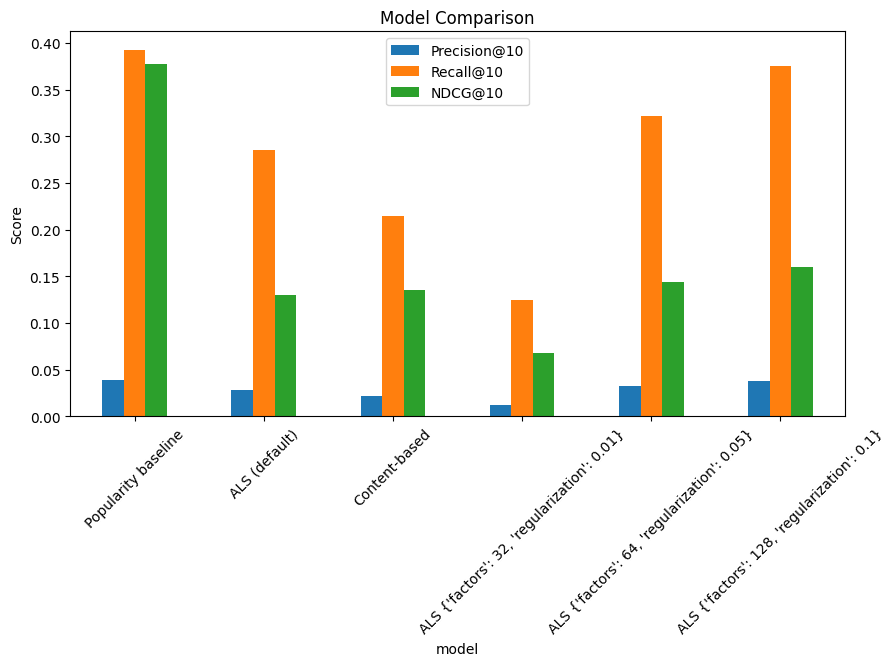

In [21]:
ax = summary.set_index("model")[["Precision@10","Recall@10","NDCG@10"]].plot(
    kind="bar", figsize=(10,5), rot=45
)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
plt.show()

In [22]:
interactions["SteamId"].value_counts().describe()

count     56.000000
mean     101.339286
std       88.822454
min       10.000000
25%       42.000000
50%       78.000000
75%      128.750000
max      483.000000
Name: count, dtype: float64

In [23]:
interactions["AppId"].value_counts().describe()

count    707.000000
mean       8.026874
std        4.584196
min        5.000000
25%        5.000000
50%        6.000000
75%        9.000000
max       48.000000
Name: count, dtype: float64

## Explain our choices (models + metrics)

**Why implicit feedback?**  
We only have playtime data, not explicit ratings.  
Playtime reflects interest, so we convert it into an implicit score using log scaling:
- log(1 + playtime) compresses extreme values  
- recent playtime is weighted to capture current interest

**Why ALS (matrix factorization)?**  
ALS handles sparse user‑item data and learns latent preferences.  
It is a standard baseline for implicit recommendation tasks.

**Why content‑based?**  
Content‑based models work when user history is limited and allow recommendations based on game metadata (genres/tags/reviews).

**Why compare to a popularity baseline?**  
A simple baseline tells us if sophisticated models actually improve over “recommend the most popular games.”

**Why these metrics?**  
- Precision@10: how many recommended games are relevant  
- Recall@10: whether we retrieved the held‑out item  
- NDCG@10: how highly the relevant item ranks